# EDINET データの探索的データ分析（EDA）

このノートブックでは、EDINET の財務指標と人的資本指標を段階的に分析します。

## 学習目標
- データの全体像を把握する
- 各指標の分布と特性を理解する
- 欠損値と異常値を検出・評価する
- 複数の変数間の関係を発見する

In [24]:
# 企業一覧を確認
df['company_name'].unique()[:20]  # 最初の20社

array(['株式会社竹中工務店', '高橋カーテンウォール工業株式会社', 'カンロ株式会社', 'サッポロホールディングス株式会社',
       '北海道コカ・コーラボトリング株式会社', '株式会社トーア紡コーポレーション', 'ダイナパック株式会社', 'コクヨ株式会社',
       '株式会社日本経済新聞社', 'ライオン株式会社', '住友ゴム工業株式会社', '日本電気硝子株式会社', '株式会社倉元製作所',
       '東洋炭素株式会社', '大和重工株式会社', '日本パワーファスニング株式会社', '井関農機株式会社', '日機装株式会社',
       '株式会社ハマイ', '株式会社長府製作所'], dtype=object)

In [25]:
# 方法3：DuckDB で直接クエリ（より高速）
result = conn.execute("""
    SELECT *
    FROM analytics.company_year_metrics
    WHERE company_name LIKE '%コクヨ%'
    ORDER BY fiscal_year DESC
""").fetchdf()
print(result)


  edinet_code company_name  fiscal_year    doc_id submitted_date     status  \
0      E00670      コクヨ株式会社         2023  S100T657     2024-03-29  processed   

          sales  operating_profit    net_profit  employee_count  \
0  328753000000      2.383000e+10  1.906900e+10          6931.0   

   female_manager_ratio  male_childcare_leave_ratio  gender_wage_gap  \
0                   1.0                         1.0            11.06   

  source_name  
0  EDINET_CSV  


## 1. 環境セットアップとデータ読み込み

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# フォント設定（日本語表示用）
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
sns.set_style('whitegrid')

# DuckDB に接続
db_path = '../artifacts/analytics/edinet_analytics.duckdb'
conn = duckdb.connect(db_path, read_only=True)

# メインテーブルを読み込み
df = conn.execute('SELECT * FROM analytics.company_year_metrics').fetchdf()

print(f'✅ データ読み込み完了')
print(f'形状: {df.shape[0]} 行 × {df.shape[1]} 列')

✅ データ読み込み完了
形状: 174 行 × 14 列


## 2. データの全体像を把握

### フェーズ 1：構造把握
最初にすべきことは、データが「何か」「何行あるか」「どの型か」を把握すること。

In [2]:
# データ型と基本情報
print('【データ型と情報量】')
print(df.info())
print()
print('【最初の5行】')
print(df.head())

【データ型と情報量】
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   edinet_code                 174 non-null    object        
 1   company_name                174 non-null    object        
 2   fiscal_year                 174 non-null    int64         
 3   doc_id                      174 non-null    object        
 4   submitted_date              174 non-null    datetime64[us]
 5   status                      174 non-null    object        
 6   sales                       174 non-null    int64         
 7   operating_profit            172 non-null    float64       
 8   net_profit                  172 non-null    float64       
 9   employee_count              171 non-null    float64       
 10  female_manager_ratio        140 non-null    float64       
 11  male_childcare_leave_ratio  132 non-null    flo

In [3]:
# 企業数と年度の多様性を確認
print('【企業と年度の粒度】')
print(f'ユニークな企業数: {df["edinet_code"].nunique()}')
print(f'ユニークな年度: {sorted(df["fiscal_year"].unique())}')
print(f'年度の範囲: {df["fiscal_year"].min()} - {df["fiscal_year"].max()}')
print()
print('【企業別のレコード数（上位10社）】')
print(df['company_name'].value_counts().head(10))

【企業と年度の粒度】
ユニークな企業数: 174
ユニークな年度: [np.int64(2023), np.int64(2024)]
年度の範囲: 2023 - 2024

【企業別のレコード数（上位10社）】
company_name
株式会社竹中工務店            1
ベース株式会社              1
株式会社和心               1
株式会社アクリート            1
イーソル株式会社             1
ブリッジインターナショナル株式会社    1
株式会社Ｗｅｌｂｙ            1
株式会社グッドスピード          1
株式会社パワーソリューションズ      1
コーユーレンティア株式会社        1
Name: count, dtype: int64


## 3. 単変量分析：各指標の分布

### フェーズ 2：各列を個別に分析
各変数が「どのような値を持っているか」を個別に理解。

In [4]:
# 数値列だけを抽出
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'数値列: {numeric_cols}')
print()

# 基本統計量（平均、中央値、標準偏差など）
print('【基本統計量】')
print(df[numeric_cols].describe())

数値列: ['fiscal_year', 'sales', 'operating_profit', 'net_profit', 'employee_count', 'female_manager_ratio', 'male_childcare_leave_ratio', 'gender_wage_gap']

【基本統計量】
       fiscal_year         sales  operating_profit    net_profit  \
count   174.000000  1.740000e+02      1.720000e+02  1.720000e+02   
mean   2023.011494  7.052323e+10      3.821469e+09  2.867940e+09   
std       0.106901  2.324307e+11      1.398412e+10  1.068358e+10   
min    2023.000000  1.000000e+02     -1.196750e+10 -2.618800e+10   
25%    2023.000000  2.136202e+09      1.222450e+07 -6.070000e+05   
50%    2023.000000  7.175707e+09      4.139330e+08  2.407970e+08   
75%    2023.000000  3.043728e+10      1.780250e+09  1.027872e+09   
max    2024.000000  2.018568e+12      1.396120e+11  7.104700e+10   

       employee_count  female_manager_ratio  male_childcare_leave_ratio  \
count      171.000000            140.000000                  132.000000   
mean      2274.649123             12.983286                   13.033182  

In [5]:
# ★ Insight ─────────────────────────────────────
# 基本統計量を見るときのチェックポイント：
# 1. 平均と中央値（mean vs 50%）の違い → 外れ値や歪みの有無を示唆
# 2. min/max の範囲 → 妥当な値か、データ入力エラー可能性
# 3. 標準偏差（std） → 値のばらつきの大きさ
# ─────────────────────────────────────────────────

# 売上高の例：平均と中央値の比較
sales_mean = df['sales'].mean()
sales_median = df['sales'].median()
print(f'\n売上高の平均: {sales_mean:,.0f} 円')
print(f'売上高の中央値: {sales_median:,.0f} 円')
print(f'差分: {(sales_mean - sales_median):,.0f} 円')
print(f'\n→ 平均 > 中央値 の場合、大きな売上の企業が数社存在する可能性（右に裾引いた分布）')


売上高の平均: 70,523,233,397 円
売上高の中央値: 7,175,707,000 円
差分: 63,347,526,397 円

→ 平均 > 中央値 の場合、大きな売上の企業が数社存在する可能性（右に裾引いた分布）


/var/folders/6g/r65g93w51212q1sz5l6kq2lr0000gn/T/ipykernel_64635/621856384.py:19: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6g/r65g93w51212q1sz5l6kq2lr0000gn/T/ipykernel_64635/621856384.py:19: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6g/r65g93w51212q1sz5l6kq2lr0000gn/T/ipykernel_64635/621856384.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6g/r65g93w51212q1sz5l6kq2lr0000gn/T/ipykernel_64635/621856384.py:19: UserWarning: Glyph 27424 (\N{CJK UNIFIED IDEOGRAPH-6B20}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6g/r65g93w51212q1sz5l6kq2lr0000gn/T/ipykernel_64635/621856384.py:19: UserWarning: Glyph 25613 (\N{CJK UNIFIED IDEOGRAPH-640D}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6g/r65g93w51212q1sz5l6kq2lr0000gn/T/ipyker

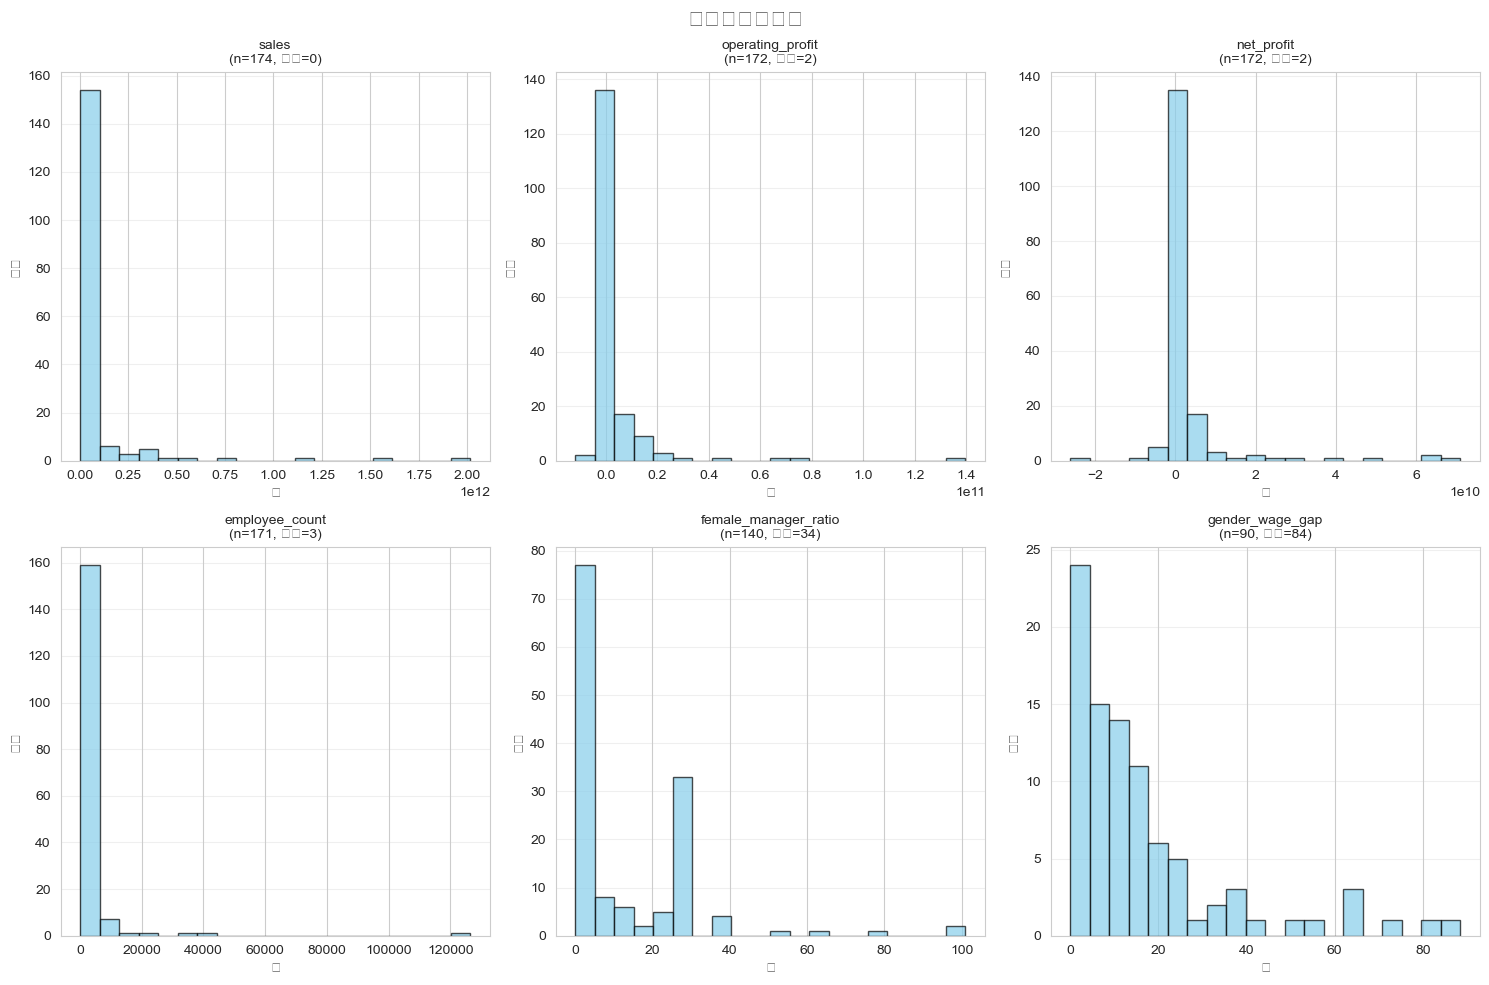

✅ ヒストグラムを保存しました


In [6]:
# 各指標のヒストグラム（分布を可視化）
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('主要指標の分布', fontsize=16, fontweight='bold')

metrics = ['sales', 'operating_profit', 'net_profit', 'employee_count', 
           'female_manager_ratio', 'gender_wage_gap']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    
    # 欠損値を除いてプロット
    data = df[metric].dropna()
    ax.hist(data, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{metric}\n(n={len(data)}, 欠損={len(df) - len(data)})', fontsize=10)
    ax.set_xlabel('値')
    ax.set_ylabel('度数')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../artifacts/eda_01_histograms.png', dpi=100, bbox_inches='tight')
plt.show()

print('✅ ヒストグラムを保存しました')

## 4. 欠損値の確認

### フェーズ 3：データ品質の評価
欠損値の多さと分布パターンは、後の分析戦略に直結する。

In [7]:
# 欠損値の件数と割合
print('【欠損値の分析】')
missing = pd.DataFrame({
    '欠損件数': df.isnull().sum(),
    '欠損率(%)': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('欠損率(%)', ascending=False)

print(missing)
print()

# ★ Insight ─────────────────────────────────────
# 欠損値の意味：
# - sales/operating_profit/net_profit: 企業が開示していない（公開企業じゃない等）
# - female_manager_ratio など: 新しい指標で、古い年度では未開示
# - 欠損率 > 50% の指標は、全体分析より「欠損の多い層」を別途分析すべき
# ─────────────────────────────────────────────────

# 欠損パターン：年度別に見ると、新しい指標ほど古い年度で欠損が多いはず
print('【年度別の欠損件数】')
missing_by_year = df.groupby('fiscal_year').apply(lambda x: x.isnull().sum())
print(missing_by_year[['sales', 'female_manager_ratio', 'male_childcare_leave_ratio']])

【欠損値の分析】
                            欠損件数  欠損率(%)
gender_wage_gap               84    48.3
male_childcare_leave_ratio    42    24.1
female_manager_ratio          34    19.5
source_name                   34    19.5
employee_count                 3     1.7
operating_profit               2     1.1
net_profit                     2     1.1
edinet_code                    0     0.0
company_name                   0     0.0
fiscal_year                    0     0.0
doc_id                         0     0.0
submitted_date                 0     0.0
status                         0     0.0
sales                          0     0.0

【年度別の欠損件数】
             sales  female_manager_ratio  male_childcare_leave_ratio
fiscal_year                                                         
2023             0                    32                          40
2024             0                     2                           2


/var/folders/6g/r65g93w51212q1sz5l6kq2lr0000gn/T/ipykernel_64635/839907822.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_year = df.groupby('fiscal_year').apply(lambda x: x.isnull().sum())


In [ ]:
# 欠損値の可視化（ヒートマップ）
fig, ax = plt.subplots(figsize=(12, 6))

# 欠損値を 0/1 にして可視化
missing_matrix = df[numeric_cols].isnull().astype(int)
missing_by_col = missing_matrix.sum().sort_values(ascending=False)

ax.barh(range(len(missing_by_col)), missing_by_col.values, color='coral')
ax.set_yticks(range(len(missing_by_col)))
ax.set_yticklabels(missing_by_col.index)
ax.set_xlabel('欠損件数')
ax.set_title('指標別の欠損値数', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# 数値ラベルを追加
for i, v in enumerate(missing_by_col.values):
    ax.text(v + 1, i, str(v), va='center')

plt.tight_layout()
plt.savefig('../artifacts/eda_02_missing_values.png', dpi=100, bbox_inches='tight')
plt.show()

print('✅ 欠損値チャートを保存しました')

## 5. 異常値（アウトライア）の検出

### フェーズ 4：妥当性チェック
データに入力エラーや測定ミスがないか確認。

In [ ]:
# ★ Insight ─────────────────────────────────────
# 異常値検出の方法：
# 1. IQR法（四分位範囲）：Q1 - 1.5×IQR 以下、Q3 + 1.5×IQR 以上 → 異常
# 2. Z-score：|z| > 3 を異常と判定（標準偏差3個分以上）
# 3. ドメイン知識：業界の常識に反する値
# ─────────────────────────────────────────────────

def detect_outliers_iqr(data):
    """IQR法で異常値を検出"""
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data < lower_bound) | (data > upper_bound)

# 売上高で異常値を検出
print('【売上高の異常値検出（IQR法）】')
outliers = detect_outliers_iqr(df['sales'].dropna())
print(f'異常値件数: {outliers.sum()}')

if outliers.sum() > 0:
    print('\n異常値（極度に大きい売上）：')
    print(df.loc[df['sales'].dropna().index[outliers], 
                 ['company_name', 'fiscal_year', 'sales']].sort_values('sales', ascending=False))

In [ ]:
# 箱ひげ図で異常値を可視化
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('異常値の可視化（箱ひげ図）', fontsize=14, fontweight='bold')

# 売上、利益、従業員数の箱ひげ図
for idx, col in enumerate(['sales', 'operating_profit', 'employee_count']):
    ax = axes[idx]
    data = df[col].dropna()
    
    ax.boxplot(data, vert=True)
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('値')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../artifacts/eda_03_outliers.png', dpi=100, bbox_inches='tight')
plt.show()

print('✅ 箱ひげ図を保存しました')

## 6. 多変量分析：変数間の関係

### フェーズ 5：パターン発見
単体では見えない、複数の変数間の関係を探索。

In [ ]:
# 相関行列の計算
print('【数値変数間の相関係数】')
correlation = df[numeric_cols].corr()
print(correlation.round(3))

# ★ Insight ─────────────────────────────────────
# 相関係数の解釈：
# |r| > 0.7: 強い相関（一方が増えると他方も増える傾向）
# 0.4 < |r| < 0.7: 中程度の相関
# |r| < 0.4: 弱い相関
# 相関 = 因果ではない！（混乱変数の存在を常に考える）
# ─────────────────────────────────────────────────

print('\n【強い相関を持つペア】')
# 相関行列の上三角を取得（重複を避けるため）
for i in range(len(correlation.columns)):
    for j in range(i+1, len(correlation.columns)):
        corr_value = correlation.iloc[i, j]
        if abs(corr_value) > 0.5:  # 相関が 0.5 以上の組み合わせを抽出
            col1, col2 = correlation.columns[i], correlation.columns[j]
            print(f'{col1} ↔ {col2}: {corr_value:.3f}')

In [ ]:
# 相関行列のヒートマップ
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('相関行列（数値変数間）', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../artifacts/eda_04_correlation.png', dpi=100, bbox_inches='tight')
plt.show()

print('✅ 相関ヒートマップを保存しました')

In [ ]:
# 企業規模と女性管理職比率の関係を散布図で確認
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('企業規模と人的資本指標の関係', fontsize=14, fontweight='bold')

# 左図：売上高と女性管理職比率
ax = axes[0]
valid_data = df[['sales', 'female_manager_ratio']].dropna()
ax.scatter(valid_data['sales'], valid_data['female_manager_ratio'], 
          alpha=0.6, s=50, color='steelblue')
ax.set_xlabel('売上高（円）')
ax.set_ylabel('女性管理職比率（%）')
ax.set_title(f'売上 vs 女性管理職比率 (n={len(valid_data)})')
ax.grid(alpha=0.3)

# 相関係数を表示
corr_coef = valid_data['sales'].corr(valid_data['female_manager_ratio'])
ax.text(0.05, 0.95, f'相関係数 r = {corr_coef:.3f}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 右図：従業員数と男女賃金格差
ax = axes[1]
valid_data2 = df[['employee_count', 'gender_wage_gap']].dropna()
ax.scatter(valid_data2['employee_count'], valid_data2['gender_wage_gap'], 
          alpha=0.6, s=50, color='darkgreen')
ax.set_xlabel('従業員数')
ax.set_ylabel('男女賃金格差（%）')
ax.set_title(f'従業員数 vs 男女賃金格差 (n={len(valid_data2)})')
ax.grid(alpha=0.3)

corr_coef2 = valid_data2['employee_count'].corr(valid_data2['gender_wage_gap'])
ax.text(0.05, 0.95, f'相関係数 r = {corr_coef2:.3f}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.savefig('../artifacts/eda_05_scatter.png', dpi=100, bbox_inches='tight')
plt.show()

print('✅ 散布図を保存しました')

## 7. 時系列分析：年度別トレンド

### フェーズ 6：時間軸での変化
同じ指標が年度を通じてどう変わるか。

In [ ]:
# 年度別の平均値を計算
print('【年度別の指標平均】')
yearly_avg = df.groupby('fiscal_year')[numeric_cols].mean().round(2)
print(yearly_avg)

In [ ]:
# 年度別トレンドの可視化
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('年度別の指標トレンド', fontsize=14, fontweight='bold')

metrics_to_plot = ['sales', 'employee_count', 'female_manager_ratio', 
                   'male_childcare_leave_ratio', 'gender_wage_gap', 'operating_profit']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    yearly_data = df.groupby('fiscal_year')[metric].agg(['mean', 'count'])
    
    # 平均値を折れ線グラフで
    ax.plot(yearly_data.index, yearly_data['mean'], marker='o', linewidth=2, markersize=6, color='steelblue')
    ax.set_title(f'{metric}\n(平均値の推移)', fontsize=10)
    ax.set_xlabel('会計年度')
    ax.set_ylabel('値')
    ax.grid(alpha=0.3)
    
    # サンプル数を下に表示
    ax.text(0.5, -0.15, f"※ サンプル数: {yearly_data['count'].to_dict()}",
           transform=ax.transAxes, fontsize=8, ha='center')

plt.tight_layout()
plt.savefig('../artifacts/eda_06_trends.png', dpi=100, bbox_inches='tight')
plt.show()

print('✅ トレンドチャートを保存しました')

## 8. EDA まとめ：発見と仮説

In [ ]:
print('\n' + '='*60)
print('📊 EDA 分析サマリー')
print('='*60)

print(f'\n【データセット】')
print(f'  • 企業数: {df["edinet_code"].nunique()} 社')
print(f'  • 年度: {df["fiscal_year"].min()} - {df["fiscal_year"].max()}')
print(f'  • レコード数: {len(df)} 行')

print(f'\n【指標の充足率】')
for col in ['sales', 'operating_profit', 'employee_count', 'female_manager_ratio']:
    valid = df[col].notna().sum()
    pct = valid / len(df) * 100
    print(f'  • {col}: {valid}/{len(df)} ({pct:.1f}%)')

print(f'\n【主な発見】')
print(f'  1. 売上高: 平均 {df["sales"].mean():,.0f} 円、中央値 {df["sales"].median():,.0f} 円')
print(f'     → 大企業が複数存在（平均 > 中央値）')
print(f'\n  2. 人的資本指標は新しい指標ほど欠損が多い')
print(f'     → 女性管理職比率: {df["female_manager_ratio"].notna().sum()} 件')
print(f'     → 育休取得率: {df["male_childcare_leave_ratio"].notna().sum()} 件')
print(f'\n  3. 売上と女性管理職比率の相関は弱い (r={df["sales"].corr(df["female_manager_ratio"]):.3f})')
print(f'     → 企業規模と人事施策は直結しない可能性')

print(f'\n【次のステップで検討する仮説】')
print(f'  □ 女性管理職比率が高い企業の特性は？（業種、規模）')
print(f'  □ 年度による推移：女性管理職比率は上昇傾向か？')
print(f'  □ 利益率（営業利益/売上）で企業を分類したとき、人的資本指標は異なるか')
print(f'  □ 育休取得率と男女賃金格差の関係は？')
print('='*60)